In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
%matplotlib inline
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import networkx as nx
from statsmodels.nonparametric.smoothers_lowess import lowess

# Reading QC File via data preparation module

config.yaml stores file paths, sheet numbers, and header row positions for each bioreplicate.
The code extracts the QC section under biorep1.
This allows automatic switching between biorep1 / biorep2 / future datasets without changing code.

In [5]:

import yaml
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import read_qc_file

#  Load configuration
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"

with open(config_path, "r") as file:
    config = yaml.safe_load(file)

#  Extract QC settings from the config
qc_config = config["biorep1"]["qc_file"]


# Use config values to read the QC file
qc_data = read_qc_file(
    qc_config["path"],
    sheet_index=qc_config.get("sheet_index", 0),
    header_row=qc_config.get("header_row", 12),
    preview_rows=qc_config.get("preview_rows", 5)
)

#  Print confirmation and preview
print("\n QC data successfully loaded using configuration.\n")
print(qc_data.head())



 File successfully read as Excel (.xlsx)

 Preview of QC data:
   Peak    tR1    tR2     tR  m/z  \
0     1  1.864  1.949  1.906   40   
1     2  1.905  1.991  1.948   44   
2     3  1.925  2.003  1.964   81   
3     4  1.940  2.039  1.990   64   
4     5  1.960  2.090  2.025   42   

                                            ID Names  s1 S96_QC1_B1_D1_T1  \
0    0.15%  || 40                                ...                44728   
1    1.81%  || 44                                ...               354392   
2    0.14%  || 81   69  169  119                 ...                75703   
3    0.80%  || 64   48   61   66   96   37  131  ...               238856   
4    0.82%  || 42  41  40  39  38  50            ...               207592   

   s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  ...  \
0                46928                46096                44488  ...   
1               461936               609704                92652  ...   
2                27041          

This output shows the  QC peak table  loaded from Excel, and it provides the baseline data like retention time, peaks and qc samples needed for drift correction, peak filtering, and normalization in the preprocessing pipeline.

# Biorep1 QC Data Cleaning and Standardization Workflow

This block extracts the valid T1 signals, calculates retention time stability metrics, generates a clean QC table with tR_best, and saves it for downstream drift correction and peak filtering.

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import clean_qc_data



# Load configuration

config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"

with open(config_path, "r") as file:
    config = yaml.safe_load(file)

#  Biorep1 section
qc_cfg = config["biorep1"]["qc_merge"]
qc_file_cfg = config["biorep1"]["qc_file"]


# Load QC data
qc_path = qc_file_cfg["path"]
sheet_index = qc_file_cfg.get("sheet_index", 0)
header_row = qc_file_cfg.get("header_row", 12)

if qc_path.lower().endswith(".xlsx"):
    print(" Reading QC file as Excel (.xlsx)...")
    qc_data = pd.read_excel(qc_path, sheet_name=sheet_index, header=header_row)
else:
    print(" Reading QC file as CSV...")
    qc_data = pd.read_csv(qc_path, header=header_row)

print(f"\n QC data loaded from: {qc_path}")
print(f" Data shape: {qc_data.shape}")

# Clean and save QC data
output_path = qc_cfg["qc_path"]

# Ensure output directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Clean QC data 
cleaned_qc = clean_qc_data(
    qc_data=qc_data,
    output_path=output_path
)

print(f"\n QC data cleaned and saved successfully for {"biorep1"}!")
print(f" Output saved at: {output_path}")



 Reading QC file as Excel (.xlsx)...

 QC data loaded from: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/msmetrix_data/QC_msmetrix.xlsx
 Data shape: (589, 46)
Selected T1 columns (40): ['s1 S96_QC1_B1_D1_T1', 's2 S96_QC2_B1_D1_T1', 's3 S96_QC3_B1_D1_T1', 's4 S96_QC4_B1_D1_T1', 's5 S96_QC1_B1_D2_T1', 's6 S96_QC2_B1_D2_T1', 's7 S96_QC3_B1_D2_T1', 's8 S96_QC4_B1_D2_T1', 's9 S96_QC1_B1_D3_T1', 's10 S96_QC2_B1_D3_T1', 's11 S96_QC3_B1_D3_T1', 's12 S96_QC4_B1_D3_T1', 's13 S96_QC2_B1_D4_T1', 's14 S96_QC3_B1_D4_T1', 's15 S96_QC4_B1_D4_T1', 's16 S96_QC1_B1_D4_T1', 's17 S96_QC1_B1_D5_T1', 's18 S96_QC1_B1_D9_T1', 's19 S96_QC2_B1_D5_T1', 's20 S96_QC2_B1_D9_T1', 's21 S96_QC3_B1_D5_T1', 's22 S96_QC3_B1_D9_T1', 's23 S96_QC4_B1_D5_T1', 's24 S96_QC4_B1_D9_T1', 's25 S96_QC1_B1_D10_T1', 's26 S96_QC1_B1_D6_T1', 's27 S96_QC1_B1_D7_T1', 's28 S96_QC1_B1_D8_T1', 's29 S96_QC3_B1_D10_T1', 's30 S96_QC3_B1_D6_T1', 's31 S96_QC3_B1_D7_T1', 's32 S96_QC4_B1_D10_T1', 's33 S96_QC4_B1_D6_T1',

We detected 589 peaks and extracted 40 T1 QC injections, which represent the first run of each QC sample across multiple days.tR1 and tR2 are very close (mean difference ~0.033 min), and their mutual difference (~0.066 min) reflects normal GC variation.
The averaged retention time (tR_best) matches the reported tR almost perfectly (mean deviation ~0.00024), showing excellent peak alignment.
After removing redundant RT columns and keeping only metadata and T1 intensities, the cleaned QC dataset contains 589 peaks and 43 columns.

# QC Data loading and cleaning

The two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.

This dataframe includes three metadata column and 40 qc samples

for samples we just used T1 from our sample data beacuse T1 and T2 were the experiments with the same peaks and they were reproducible. just in two case our samples data had problem and we used T2(sample 46, 47)

# Load sample data and Potato Data Preparation: Filter and Save Selected Samples

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import filter_potato_data, clean_potato_data


# Load configuration file

config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"
with open(config_path, "r") as file:
    config = yaml.safe_load(file)

# Extract configuration for Biorep1 potato data
potato_cfg = config["biorep1"]["potato_file"]


# Filter dataset using IDs from config

filtered = filter_potato_data(
    input_path=potato_cfg["input_path"],
    output_path=potato_cfg["filtered_output_path"],
    final_normalized_ids=potato_cfg["final_normalized_ids"]
)


# Clean filtered dataset and save output
selected_data = clean_potato_data(
    filtered,
    output_path=potato_cfg["cleaned_output_path"]
)

print("\n Potato data successfully filtered and cleaned for biorep1!")
print(f" Filtered file: {potato_cfg['filtered_output_path']}")
print(f" Cleaned file: {potato_cfg['cleaned_output_path']}")



 Reading input file: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/final_sample_1-10.xlsx
 Dataset saved with 94 samples + metadata columns at:
C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/bio_rep1/potato_data_filtered_94_samples.xlsx

🧹 Cleaning potato dataset and computing tR_best...
abs(tR - tR1):
 count    602.000000
mean       0.054683
std        0.037511
min        0.016000
25%        0.031000
50%        0.045000
75%        0.068000
max        0.373000
dtype: float64 

abs(tR - tR2):
 count    602.000000
mean       0.054701
std        0.037530
min        0.016000
25%        0.030250
50%        0.045000
75%        0.068000
max        0.373000
dtype: float64 

abs(tR1 - tR2):
 count    602.000000
mean       0.109384
std        0.075038
min        0.032000
25%        0.061000
50%        0.090000
75%        0.136000
max        0.746000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    602.000000
mean       0.000253
std        0.000250

# Peak detection for qc data(compound identification)

Since qcs have seven alkane peaks we should identify them in our data.

 Found 7 alkane matches within ±0.05 tR and ±0.2 m/z tolerance.


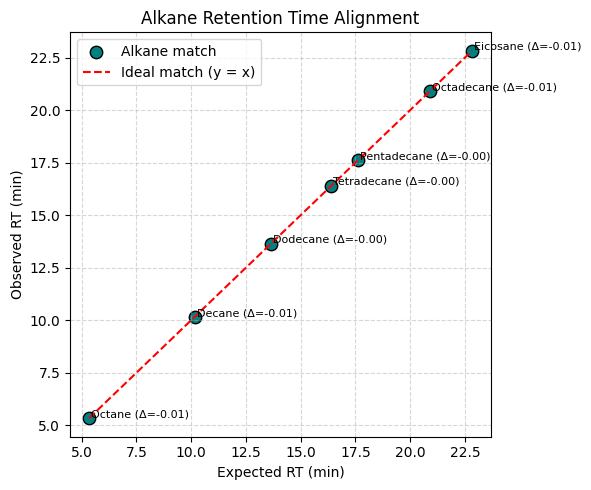

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import  match_alkanes, plot_alkane_alignment

#  Match alkanes
alkane_matches = match_alkanes(cleaned_qc, rt_tolerance=0.05, mz_tolerance=0.2)

#  Plot retention time alignment
plot_alkane_alignment(alkane_matches)


We saw that the closest  peak with retention time of octane, has m/z= 43 so we take it to consideration for further analysis

# Merge QC GC-MS Data with Master Metadata and Filter for QC Samples to have injection order for further analysis

The function merge_qc_with_master() links the cleaned QC GC–MS peak table to the master metadata by converting the wide intensity matrix into long format, extracting each sample filename from the column headers, and merging in Sample, Day, and Injection_order. It then keeps only QC samples, producing a tidy QC dataset (df_qc) ready for drift and injection-order QC plots.

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import merge_qc_with_master
import inspect
print(inspect.getsource(datapreparation_module.merge_qc_with_master))


# Extract config for biorep1
qc_merge_cfg = config["biorep1"]["qc_merge"]

# Run Merge using Config Paths
df_qc = merge_qc_with_master(
    file_master=qc_merge_cfg["master_path"],
    file_qc=qc_merge_cfg["qc_path"]
)


# Display result info
print("\n Merged QC–Master data saved successfully for biorep1:")
print(f" Output file: {qc_merge_cfg['output_path']}")
print(f" Final merged shape: {df_qc.shape}")

display(df_qc.head())

def merge_qc_with_master(file_master, file_qc):
    """
    Merges cleaned QC GC-MS data with the experiment master table metadata.

    Steps:
    1. Reads the master table (CSV) and cleaned QC file (CSV).
    2. Converts the wide QC table into long (tidy) format using melt().
    3. Extracts sample filenames from column headers.
    4. Merges with metadata (Sample, Day, Injection order).
    5. Filters only QC samples (Sample names starting with 'QC').

    Parameters
    ----------
    file_master : str
        Path to the master metadata table CSV file.
    file_qc : str
        Path to the cleaned QC dataset CSV file.

    Returns
    -------
    pd.DataFrame
        A merged DataFrame containing QC samples with associated metadata.
    """

    # Load both input files
    master_table = pd.read_csv(file_master)
    cleaned_qc = pd.read_csv(file_qc)

    # Reshape from wide to long format
    df_long_qc = cleaned_qc.melt(
        id_vars=["Peak", "tR_best", "m/z"],
        var_nam

,Peak,tR_best,m/z,SampleCol,Intensity,Filename,Sample,Day,Injection_order
0,1,1.9065,40,s1 S96_QC1_B1_D1_T1,44728,S96_QC1_B1_D1_T1,QC1,1,4
1,2,1.9480,44,s1 S96_QC1_B1_D1_T1,354392,S96_QC1_B1_D1_T1,QC1,1,4
2,3,1.9640,81,s1 S96_QC1_B1_D1_T1,75703,S96_QC1_B1_D1_T1,QC1,1,4
3,4,1.9895,64,s1 S96_QC1_B1_D1_T1,238856,S96_QC1_B1_D1_T1,QC1,1,4
4,5,2.0250,42,s1 S96_QC1_B1_D1_T1,207592,S96_QC1_B1_D1_T1,QC1,1,4


# Check QC1–QC4 linearity per day

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import evaluate_qc_linearity
results_df = evaluate_qc_linearity(alkane_matches, df_qc)
display(results_df.head())


 Evaluated QC linearity for 70 (Compound, Day) combinations.


,Compound,Peak,Day,tR_best,m/z,R2
0,Decane,165.0,1,10.147,57,0.929876
1,Decane,165.0,2,10.147,57,0.935976
2,Decane,165.0,3,10.147,57,0.927174
3,Decane,165.0,4,10.147,57,0.940022
4,Decane,165.0,5,10.147,57,0.906831


 Alkanes were detected in QC samples, and their intensities show strong linear relationships with QC order, confirming their use as internal standards for quality control.

# Dashboard for daily QC Linear Trend Analysis and Identification of Stable Peaks

In [11]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import launch_qc_linearity_dashboard

launch_qc_linearity_dashboard(df_qc, results_df, port=8020)


 Launching QC Linear Trend Dashboard at http://127.0.0.1:8020


it’s a dashboard to visualize QC linear trends per day with regression fits.

# Filter Stable QC Peaks by R² Linearity Threshold

In [ ]:

import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import filter_stable_peaks_by_r2

stable_peaks = filter_stable_peaks_by_r2(results_df, r2_threshold=0.9)

print("\nStable peak IDs:", stable_peaks["Peak"].unique())


 Found 7 unique stable peaks across 10 days (R² ≥ 0.9)
    Day     Compound   Peak  tR_best  m/z        R2
0     1       Decane  165.0  10.1470   57  0.929876
10    1     Dodecane  268.0  13.6230   57  0.941311
20    1     Eicosane  569.0  22.8185   57  0.992443
30    1   Octadecane  505.0  20.8990   57  0.994702
40    1       Octane   71.0   5.3270   43  0.981839
50    1  Pentadecane  398.0  17.6165   57  0.993057
60    1  Tetradecane  354.0  16.3845   57  0.994743
1     2       Decane  165.0  10.1470   57  0.935976
11    2     Dodecane  268.0  13.6230   57  0.921506
21    2     Eicosane  569.0  22.8185   57  0.957044
31    2   Octadecane  505.0  20.8990   57  0.946656
41    2       Octane   71.0   5.3270   43  0.977451
51    2  Pentadecane  398.0  17.6165   57  0.941682
61    2  Tetradecane  354.0  16.3845   57  0.909702
2     3       Decane  165.0  10.1470   57  0.927174
12    3     Dodecane  268.0  13.6230   57  0.933338
22    3     Eicosane  569.0  22.8185   57  0.985585
32    3  

The most stable qc peaks were  165. 268. 569. 505.  71. 398. 354 so we use them for normalization

# Perform One-Way ANOVA to Assess Day-to-Day QC Intensity Stability

In [13]:

import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import perform_anova_on_qc_peaks

anova_df = perform_anova_on_qc_peaks(df_qc, results_df)

display(anova_df.head())


 ANOVA completed for 7 peaks across days.
Significant (p<0.05): 0 peaks


,Compound,Peak,tR_best,m/z,ANOVA_F,ANOVA_p
0,Decane,165,10.1470,57,0.170037,0.995765
1,Dodecane,268,13.6230,57,0.183495,0.994380
2,Eicosane,569,22.8185,57,0.740809,0.669151
3,Octadecane,505,20.8990,57,0.259590,0.980791
4,Octane,71,5.3270,43,0.263964,0.979676


ANOVA shows no, they do not differ across biological groups (they’re chemically stable references.

# Visualize QC Injection Stability Using LOESS Smoothing

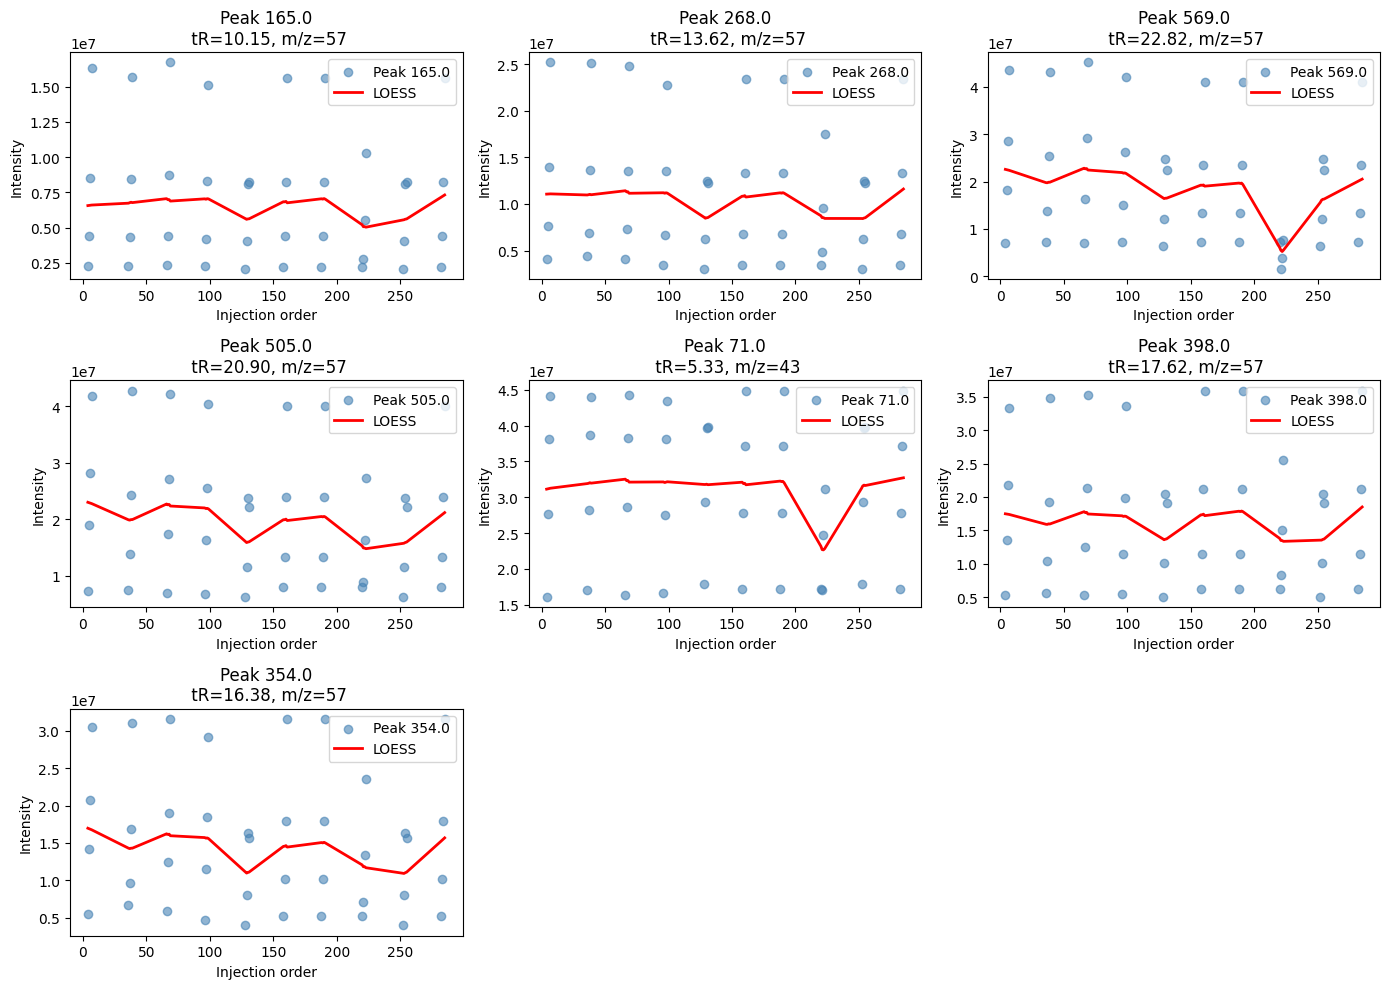

 Displayed LOESS trends for 7 stable peaks.


In [14]:


import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import plot_loess_trends_for_stable_peaks

plot_loess_trends_for_stable_peaks(df_qc, stable_peaks, max_plots=9, frac=0.3)



This figure checks instrument stability by plotting QC peak intensity versus injection order for several stable peaks. Blue points are the raw QC measurements and the red LOESS curve (frac=0.3) summarizes the overall trend. Most LOESS lines are relatively flat with only small fluctuations, suggesting limited drift across the run, while a few peaks show localized drops at later injections that may indicate short periods of reduced sensitivity.

# Visualize QC Level Drift Across Injection Order for Stable Peaks by linear regression

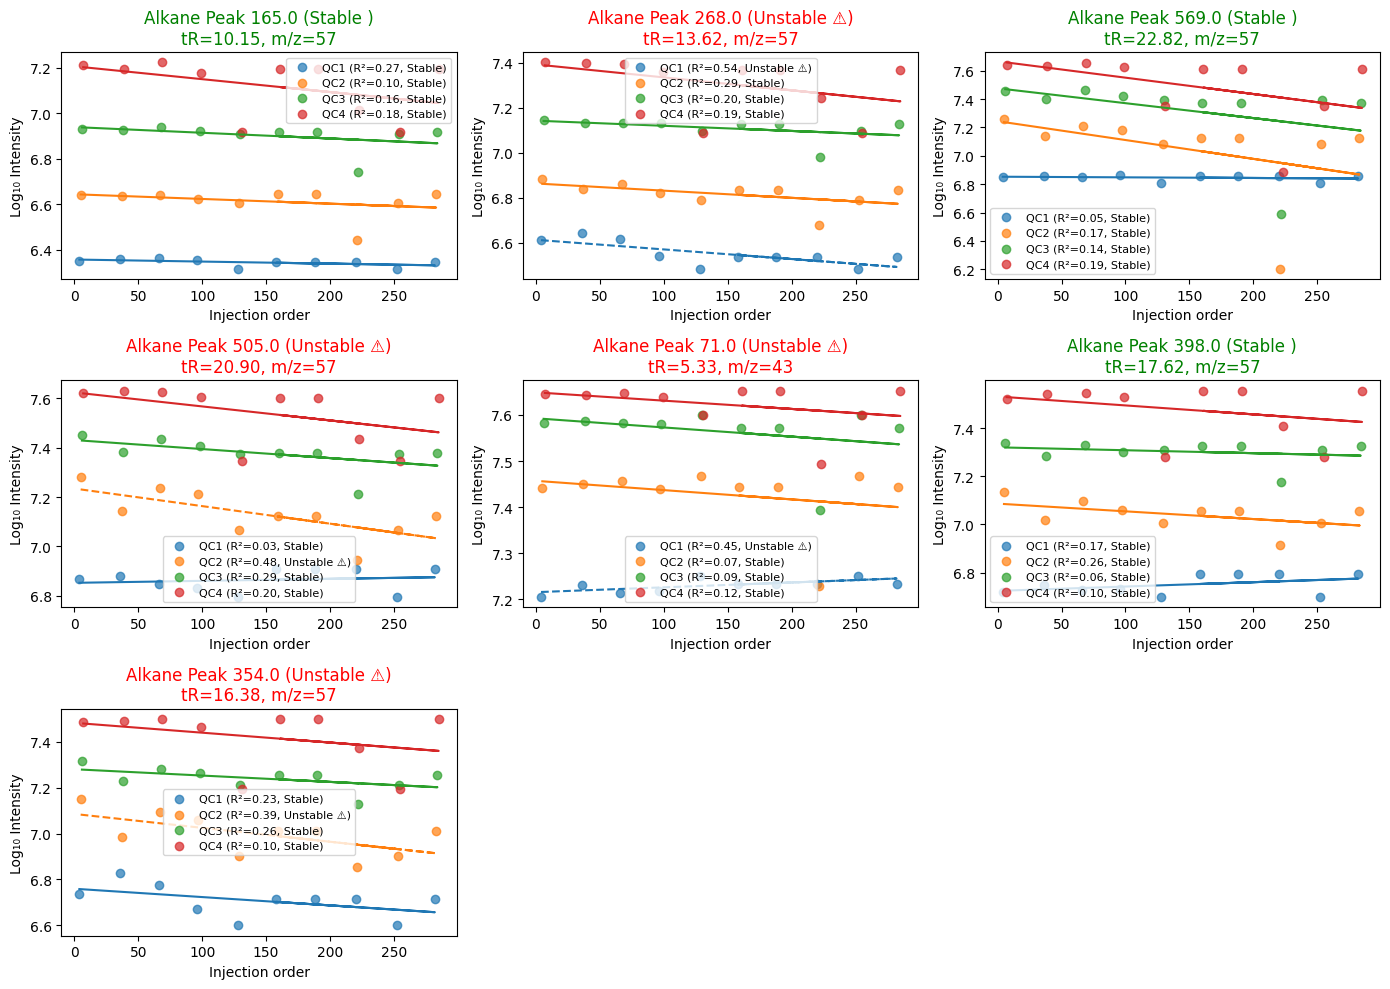

In [15]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import plot_alkane_stability_colored

stability_summary_colored = plot_alkane_stability_colored(
    df_qc=df_qc,
    stable_peaks=stable_peaks,
    r2_threshold=0.3
)


This figure evaluates alkane QC stability across the injection sequence. For each selected alkane peak (title shows tR and m/z), QC1–QC4 are plotted in different colors on a log10 intensity scale, and a separate linear trend line is fitted per QC level. Stability is judged using an R² threshold (here r2_threshold=0.3): peaks with low R² (little systematic change with injection order) are labeled Stable and shown with solid trend lines, while peaks exceeding the threshold are flagged Unstable (dashed lines). The peak title summarizes the overall status based on the worst-case QC level, helping identify which alkanes remain consistent over time and which may reflect drift or run-to-run variability that should be corrected or filtered in downstream QC.

# Optimization of LOESS Parameters for QC Drift Correction

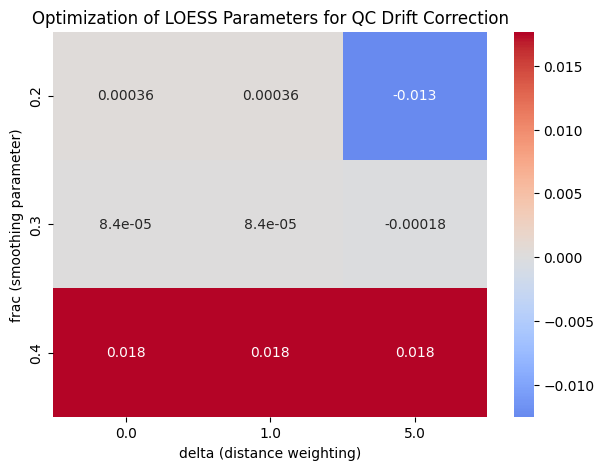

Best LOESS parameters for drift correction:
frac                0.400000
alpha               0.010000
delta               0.000000
mean_improvement    0.017665
Name: 18, dtype: float64


,frac,alpha,delta,mean_improvement
0,0.2,0.01,0.0,0.000363
1,0.2,0.01,1.0,0.000363
2,0.2,0.01,5.0,-0.012504
3,0.2,0.05,0.0,0.000363
4,0.2,0.05,1.0,0.000363


In [16]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import  optimize_loess_drift_correction

# Call the LOESS optimization function
best_params, opt_df = optimize_loess_drift_correction(df_qc, stable_peaks)

# Print the best parameter combination
print("Best LOESS parameters for drift correction:")
print(best_params)

# Display the full optimization results
display(opt_df.head())


This step optimizes the LOESS drift-correction settings using the alkane QC peaks as a stable reference. The function runs a small grid search over frac (smoothing strength) and delta (distance weighting), fits LOESS to the log10 QC alkane intensities across injection order, applies the estimated drift to all QC peaks, and evaluates each parameter set by how much it reduces systematic trends after correction (summarized as the mean R² improvement). The heatmap summarizes performance across frac and delta, and the best combination is returned as best_params for use in the final drift-correction step.

# Drift correction

 Loaded master table from: C:/Users/fatemehm/OneDrive - Royal HZPC Group/Desktop/internship/files/project file/GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv


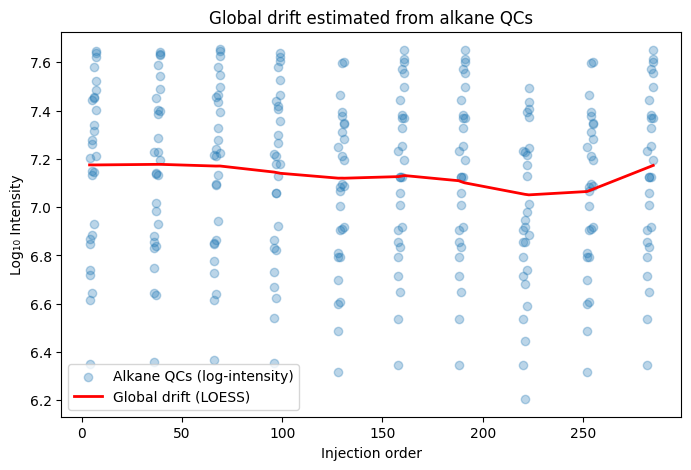

 Global QC R² before: 0.0051
 Global QC R² after : 0.0016


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\datapreparation_module.py:1003: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




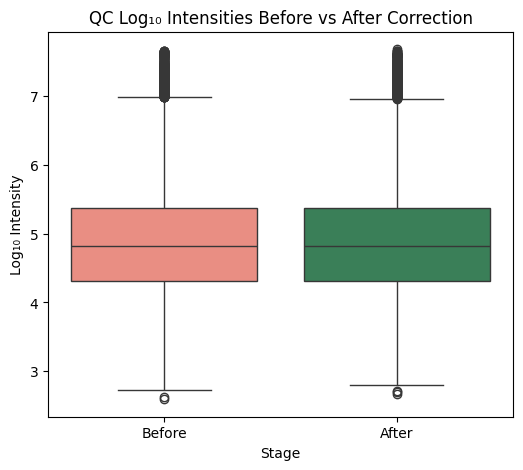

 Global sample variance before: 0.664254
 Global sample variance after : 0.661415


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\datapreparation_module.py:1026: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




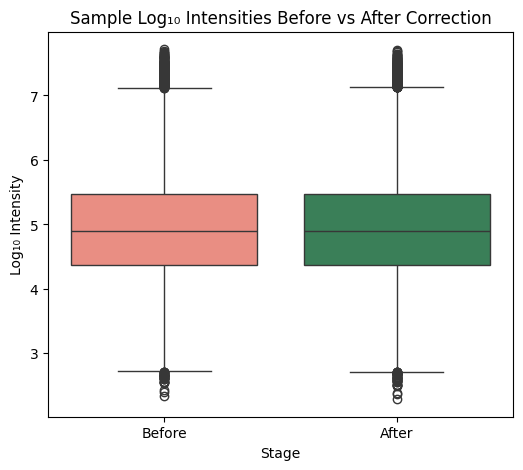

 Drift correction and global boxplot evaluation completed.


In [ ]:

import tempfile
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import apply_alkane_drift_correction_global

# Load the full config
config_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\config.yaml"
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

biorep1_config = config["biorep1"]


temp_yaml = tempfile.NamedTemporaryFile(mode="w", delete=False, suffix=".yaml", encoding="utf-8")

yaml.safe_dump(biorep1_config, temp_yaml)
temp_yaml.close()

results = apply_alkane_drift_correction_global(
    df_qc=df_qc,
    selected_data=selected_data,
    stable_peaks=stable_peaks,
    config_path=temp_yaml.name,  
    loess_frac=0.4
)

# Extract corrected data
df_corrected = results["df_corrected"]


I applied a global LOESS-based drift correction using the alkane QC peaks as a stable reference. First, alkane QC log-intensities are plotted against injection order and a LOESS curve is fitted to estimate the overall drift pattern across the run. This drift estimate was then interpolated and subtracted from the log-intensity of every peak (samples + QCs), producing an Intensity_corrected value. Finally, the effect of correction is assessed with simple before/after summaries: a global QC trend (R²) and boxplots comparing the distributions of QC and sample log-intensities before versus after correction.

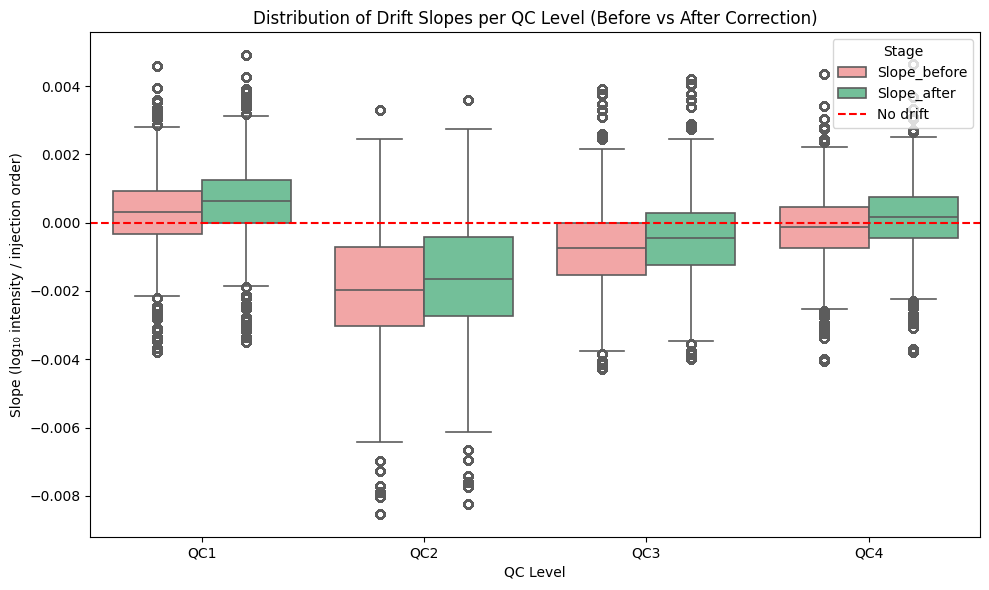


 Mean slope before correction: -0.0006578337943289077
 Mean slope after correction : -0.00036128883404714274

 Drift slope evaluation complete.


,QC,Slope_before,Slope_after
0,QC1,0.000276,0.000585
1,QC1,0.000276,0.002054
2,QC1,0.000276,-0.001195
3,QC1,0.000276,0.000160
4,QC1,0.000276,0.001708


In [18]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import plot_qc_drift_slopes

slopes_df = plot_qc_drift_slopes(df_qc=df_qc, df_corrected=df_corrected)
display(slopes_df.head())


This plot summarizes QC drift slopes before and after correction for each QC level (QC1–QC4). For every peak, a simple linear model is fitted to log10(intensity) vs injection order within each QC level, and the fitted slope represents the direction and strength of drift (red dashed line at 0 = no drift). The boxplots compare the distribution of these slopes before (Slope_before) and after (Slope_after) correction. After correction, the slope distributions move closer to zero and typically become tighter, indicating that the drift correction reduced systematic intensity changes across the run.

# Rank QCs on corrected data

QC reproducibility ranking (best → worst):
  Sample  Median_intensity        CV  Completeness     Score  Rank
0    QC1      56087.721076  3.421426           1.0  3.195945     1
1    QC2      71138.425834  3.633429           1.0  3.074890     2
2    QC3      80873.371975  4.055732           1.0  2.786341     3
3    QC4      63941.712654  5.084025           1.0  2.176571     4


c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\datapreparation_module.py:1295: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




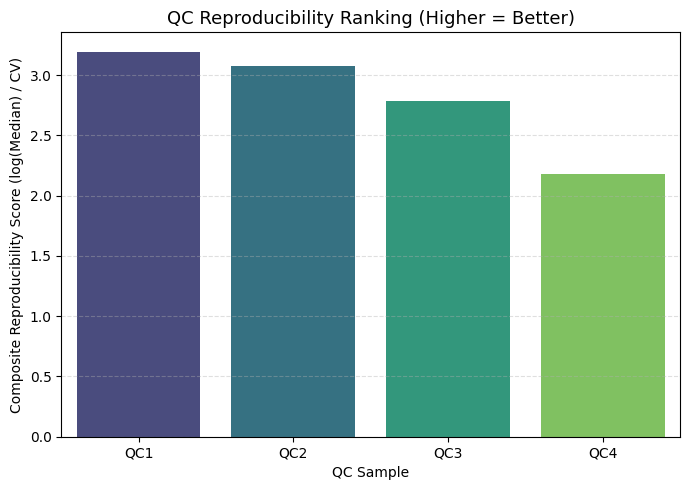

In [19]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import evaluate_qc_reproducibility, plot_qc_reproducibility
# 1. Compute QC reproducibility
qc_stats = evaluate_qc_reproducibility(df_corrected)

# 2. Plot ranking
plot_qc_reproducibility(qc_stats)



Here we assessed QC reproducibility after drift correction by summarizing each QC (QC1–QC4) using three simple metrics: the median corrected intensity, the coefficient of variation (CV) as a measure of signal stability, and completeness (fraction of non-missing values). These metrics were combined into a composite reproducibility score (log1p(median_intensity) / CV), where higher values indicate a stronger and more consistent QC signal. Based on this score, the QCs ranked QC1 > QC2 > QC3 > QC4, meaning QC1 showed the most stable performance across the run, while QC4 had the highest variability (largest CV) and therefore the lowest reproducibility score.

# Normalization by QC1

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import normalize_samples

normalized_samples = normalize_samples(df_corrected, qc_label="QC1")
# Preview result
print(normalized_samples[["Peak", "Intensity_corrected", "QC1_median",
                          "Ratio_normalized", "Log10_normalized"]].head())


 Samples normalized relative to QC1.
Number of samples normalized: 56588
Number of peaks referenced: 589
   Peak  Intensity_corrected    QC1_median  Ratio_normalized  Log10_normalized
0     1          9561.412173  46495.044729          0.205644          0.081219
1     1         18152.056716  46495.044729          0.390408          0.143142
2     1         17123.838459  46495.044729          0.368294          0.136179
3     1         14479.913782  46495.044729          0.311429          0.117745
4     1         17643.764736  46495.044729          0.379476          0.139714


This step performs QC-based normalization to make sample intensities comparable across the run. Using the drift-corrected dataset, the function takes QC1 as the reference, calculates the median corrected intensity per peak in QC1 (QC1_median), and attaches this reference value to every sample measurement of the same peak. Each sample intensity is then scaled as a ratio to QC1 (Ratio_normalized = Intensity_corrected / QC1_median), and a log-transformed version is also stored (Log10_normalized) for more stable downstream analysis. In our run, 56,588 sample measurements were normalized using 589 peaks as references from QC1.

In [ ]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import  extract_and_export_samples

samples_filtered = extract_and_export_samples(normalized_samples, output_path="samples_filtered.csv")

print(samples_filtered.head())



 Filtered samples saved to: samples_filtered.csv
Number of rows exported: 56588
          Filename                            Sample  Peak     Variety  \
0  S96_44_B1_D1_T1     NLD;MET;96;64;2024;44;FELSINA     1     FELSINA   
1  S96_14_B1_D1_T1      NLD;MET;96;64;2024;14;AVARNA     1      AVARNA   
2  S96_83_B1_D1_T1  NLD;MET;96;64;2024;83;SARPO MIRA     1  SARPO MIRA   
3   S96_9_B1_D1_T1         NLD;MET;96;64;2024;9;ANTI     1        ANTI   
4  S96_28_B1_D1_T1      NLD;MET;96;64;2024;28;CHOPIN     1      CHOPIN   

   tR_best  m/z  Intensity_corrected  Ratio_normalized  Log10_normalized  
0    1.906   40          9561.412173          0.205644          0.081219  
1    1.906   40         18152.056716          0.390408          0.143142  
2    1.906   40         17123.838459          0.368294          0.136179  
3    1.906   40         14479.913782          0.311429          0.117745  
4    1.906   40         17643.764736          0.379476          0.139714  


I prepared the final sample-level GC–MS table for downstream analysis and export. The function extract_and_export_samples() extracts the potato Variety name from the Sample field (by taking the last part after ;), keeps only the key columns (filename, sample metadata, peak identifiers, retention time, m/z, corrected and normalized intensities), and saves the cleaned result to samples_filtered.csv. In our case, the export contains 56,588 rows, providing a tidy dataset of corrected and normalized peak intensities per variety.

c:\Users\fatemehm\OneDrive - Royal HZPC Group\documents\GitHub\internship\functions\datapreparation_module.py:1436: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




 Plot saved to normalization_effect.png

 Normalization Effect Summary
Variance before normalization : 0.661415
Variance after normalization  : 0.375360
Reduction in variance         : 43.25%
{'variance_before': np.float64(0.6614147752695971), 'variance_after': np.float64(0.37536012555561016), 'reduction_percent': np.float64(43.248905287516315)}


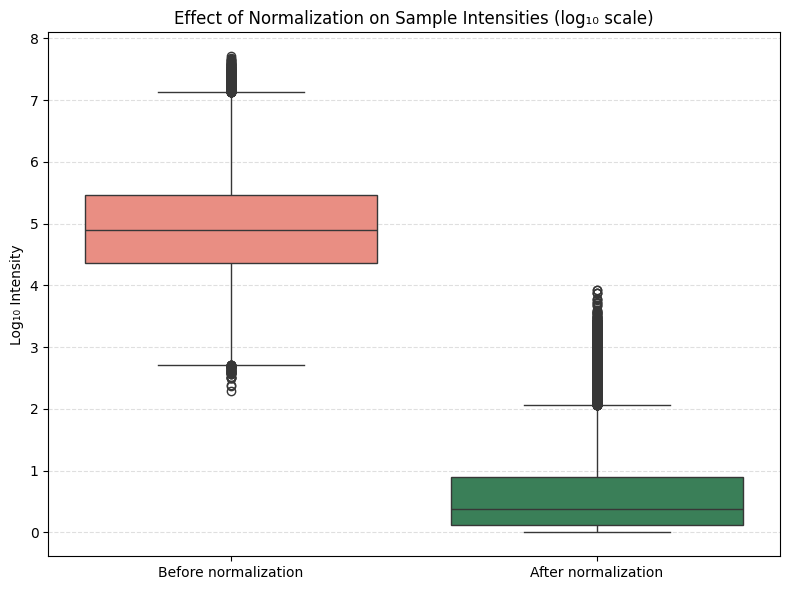

In [22]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import evaluate_normalization_effect

results = evaluate_normalization_effect(normalized_samples,
                                        output_path="normalization_effect.png")

print(results)


This plot shows how QC-based normalization (relative to QC1) changes the distribution of sample intensities on the log10 scale. Before normalization, intensities span a wide range across peaks and samples, while after normalization the values are compressed because each measurement is expressed as a ratio to the QC reference. Quantitatively, the overall variance drops from 0.661 to 0.375, corresponding to a 43.25% reduction, indicating that normalization substantially reduces global technical variation and improves comparability across samples.

# Attaching Variety Information to Sample Metadata

In [23]:
import importlib
import datapreparation_module
importlib.reload(datapreparation_module)
from datapreparation_module import attach_variety_info

samples_with_variety = attach_variety_info(normalized_samples)
print(samples_with_variety.head())


 Attached 'Variety' information for 94 varieties.
Total samples with assigned Variety: 56588
        #         Filename                            Sample  Block  Plot  \
0  1152.0  S96_44_B1_D1_T1     NLD;MET;96;64;2024;44;FELSINA    1.0   1.0   
1  1153.0  S96_14_B1_D1_T1      NLD;MET;96;64;2024;14;AVARNA    1.0   2.0   
2  1154.0  S96_83_B1_D1_T1  NLD;MET;96;64;2024;83;SARPO MIRA    1.0   3.0   
3  1155.0   S96_9_B1_D1_T1         NLD;MET;96;64;2024;9;ANTI    1.0   4.0   
4  1156.0  S96_28_B1_D1_T1      NLD;MET;96;64;2024;28;CHOPIN    1.0   5.0   

   Sample_order  Sample_date  Rep  Day  Injection_order  ...  Peak  tR_best  \
0           1.0          NaN  1.0    1               10  ...     1    1.906   
1           2.0          NaN  1.0    1               11  ...     1    1.906   
2           3.0          NaN  1.0    1               12  ...     1    1.906   
3           4.0          NaN  1.0    1               13  ...     1    1.906   
4           5.0          NaN  1.0    1           

I added a clear Variety label to each sample so the normalized GC–MS data can be analyzed at the cultivar level. The function attach_variety_info() first extracts unique (Filename, Sample) pairs, then derives the variety name by taking the last token of the Sample string (split by ;). It merges this Variety column back into the full dataset, ensuring consistent naming. As a result, all 56,588 rows receive a variety assignment, covering 94 unique varieties.